# Interpret regulator-regulator interactions

This notebook demonstrates how to infer regulator-regulator interactions network using the ChromBERT-tools Python API.

The `interpret_regulator_regulator_interactions` API generates context-aware regulator embeddings and calculates the cosine similarity of each regulator pair. Regulators with higher cosine similarity are considered more likely to interact.

For the Python CLI, see [`examples/cli/interpret_regulator_regulator_interactions.ipynb`](../cli/interpret_regulator_regulator_interactions.ipynb).

For more details, please refer to the [`interpret_regulator_regulator_interactions`](https://chrombert-tools.readthedocs.io/en/latest/commands/interpret_regulator_regulator_interactions.html) command documentation



In [1]:
from chrombert_tools import interpret_regulator_regulator_interactions

### Pre-trained

Region summary - total: 100, overlapping with ChromBERT: 100 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 3, matched in ChromBERT: 3, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Your supervised_file does not contain the 'label' column. Please verify whether ground truth column ('label') is required. If it is not needed, you may disregard this message.


100%|██████████| 2/2 [00:04<00:00,  2.24s/it]


Total graph nodes: 951
Total graph edges (threshold=0.636): 11503
Regulator subnetwork saved to: ./output_regulator_network/subnetwork_nanog_k1_q0.980_thr0.636.pdf
Regulator subnetwork saved to: ./output_regulator_network/subnetwork_ctcf_k1_q0.980_thr0.636.pdf
Regulator subnetwork saved to: ./output_regulator_network/subnetwork_ezh2_k1_q0.980_thr0.636.pdf
Finished!
Saved outputs to: ./output_regulator_network
Regulator cosine similarity saved to: ./output_regulator_network/regulator_cosine_similarity.tsv
Total graph edges saved to: ./output_regulator_network/total_graph_edge_threshold0.636_quantile0.980.tsv


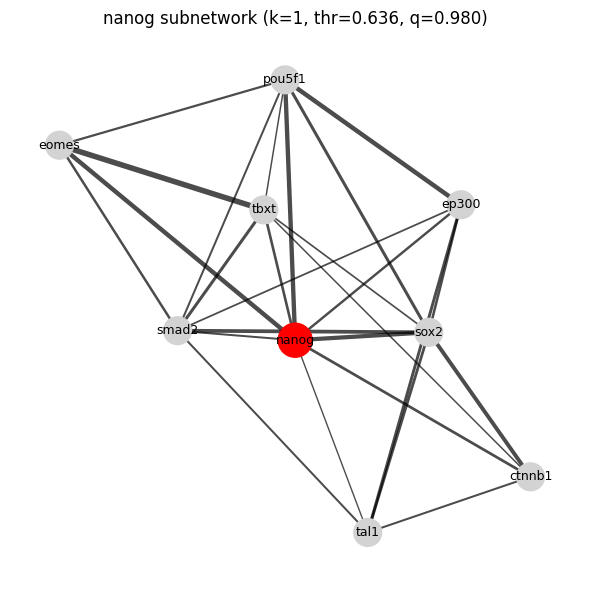

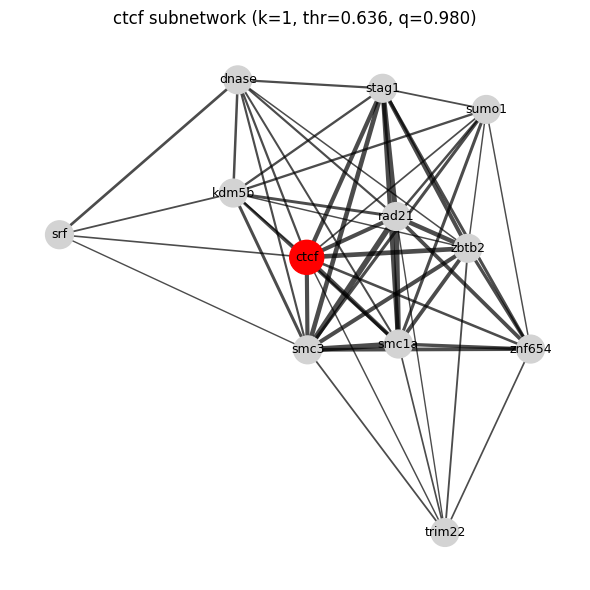

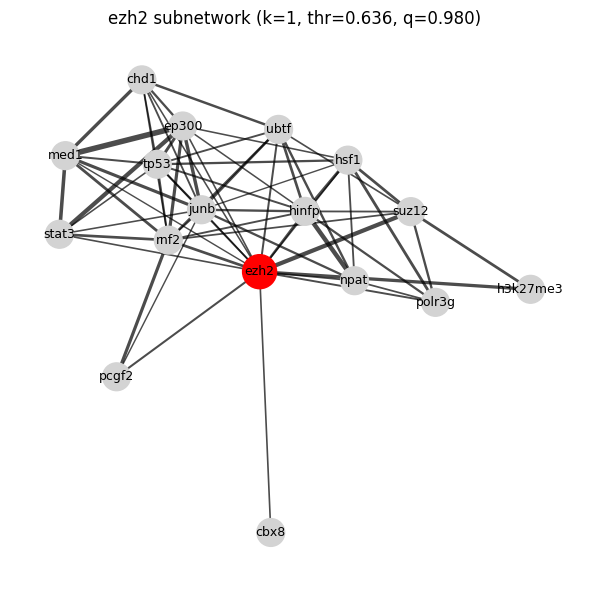

In [ ]:
# Infer regulator-regulator interactions across focus regions
# Returns:
#   all_cos_sim: cosine similarity matrix of regulator-regulator representations on focus regions; indicates interaction strength between regulators.
#   df_edges: DataFrame with columns [node1, node2, cosine_similarity]
#   Contains edges in the regulatory network where similarity >= threshold
#   Contains subnetwork visualizations for specified regulators

all_cos_sim, df_edges = interpret_regulator_regulator_interactions(
    region="../data/CTCF_ENCFF664UGR_sample100.bed",
    regulator="ctcf;nanog;ezh2",      # Plot subnetworks for these regulators
    odir="./output_regulator_network",
    genome="hg38",                      # Options: "hg38", "mm10"
    resolution="1kb",                   # Options: "1kb", "2kb", "4kb", "200bp"
)

In [4]:
# Pairwise regulator cosine similarity matrix
all_cos_sim

,5hmc,adnp,aebp2,aff1,aff4,ago1,ago2,ahr,ahrr,alkbh3,...,zscan20,zscan22,zscan23,zscan29,zscan31,zscan5a,zta,zxdb,zxdc,zzz3
5hmc,1.000000,0.161553,0.285241,0.158628,0.117248,0.127353,0.164635,0.140008,0.140390,0.256362,...,0.343546,0.136590,0.344879,0.193269,0.168963,0.255532,0.340011,0.150076,0.061059,0.330447
adnp,0.161553,1.000000,0.587140,0.387827,0.471895,0.130505,0.207243,0.277108,0.308542,0.250292,...,0.399306,0.333286,0.455049,0.514076,0.365677,0.465939,0.225964,0.436089,0.300675,0.241342
aebp2,0.285241,0.587140,1.000000,0.308597,0.402976,0.124346,0.206790,0.248920,0.429926,0.295569,...,0.407240,0.224415,0.319738,0.286058,0.308937,0.247846,0.316289,0.215994,0.166821,0.273573
aff1,0.158628,0.387827,0.308597,1.000000,0.681266,0.235524,0.285841,0.336590,0.390974,0.265273,...,0.386461,0.306672,0.318689,0.370916,0.413583,0.343913,0.262005,0.297290,0.231193,0.262453
aff4,0.117248,0.471895,0.402976,0.681266,1.000000,0.253977,0.326415,0.329043,0.368464,0.319714,...,0.380179,0.447794,0.403113,0.396646,0.423483,0.385116,0.332274,0.390634,0.394011,0.287089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zscan5a,0.255532,0.465939,0.247846,0.343913,0.385116,0.259383,0.276472,0.326592,0.212140,0.211508,...,0.757539,0.434079,0.870642,0.482686,0.472391,1.000000,0.179671,0.647394,0.424395,0.084673
zta,0.340011,0.225964,0.316289,0.262005,0.332274,0.036716,0.130013,0.184514,0.272651,0.305709,...,0.270659,0.260485,0.195705,0.184984,0.326114,0.179671,1.000000,0.087392,0.076405,0.419953
zxdb,0.150076,0.436089,0.215994,0.297290,0.390634,0.309995,0.294769,0.320665,0.209873,0.151475,...,0.573041,0.541771,0.619564,0.468207,0.393382,0.647394,0.087392,1.000000,0.497639,0.033969
zxdc,0.061059,0.300675,0.166821,0.231193,0.394011,0.333499,0.287851,0.590078,0.343713,0.153941,...,0.304457,0.302000,0.406280,0.343347,0.191912,0.424395,0.076405,0.497639,1.000000,0.017482


In [5]:
# Edge list of the regulator-regulator network.

df_edges

,node1,node2,cosine_similarity
0,5hmc,brdu,0.701982
1,5hmc,rloop,0.756476
2,5hmc,sirt1,0.664322
3,5hmc,znf823,0.641759
4,adnp,atf5,0.710570
...,...,...,...
11498,zscan20,zscan23,0.739037
11499,zscan20,zscan5a,0.757539
11500,zscan22,zscan31,0.712420
11501,zscan23,zscan5a,0.870642


In [6]:
# Edge list of the ctcf subnetwork.


df_edges_ctcf = df_edges.query("node1 == 'ctcf'")
df_edges_ctcf


,node1,node2,cosine_similarity
1682,ctcf,dnase,0.704624
1683,ctcf,kdm5b,0.658326
1684,ctcf,rad21,0.851742
1685,ctcf,smc1a,0.844970
1686,ctcf,smc3,0.856302
1687,ctcf,srf,0.656536
1688,ctcf,stag1,0.865400
1689,ctcf,sumo1,0.663740
1690,ctcf,trim22,0.642802
1691,ctcf,zbtb2,0.898986


In [7]:
# Edge list of the nanog subnetwork.
df_edges_nanog = df_edges.query("node1 == 'nanog'")
df_edges_nanog


,node1,node2,cosine_similarity
5293,nanog,pou5f1,0.755285
5294,nanog,smad2,0.660624
5295,nanog,sox2,0.749701
5296,nanog,tal1,0.636584
5297,nanog,tbxt,0.686592


In [8]:
# Edge list of the ezh2 subnetwork.
df_edges_ezh2 = df_edges.query("node1 == 'ezh2'")
df_edges_ezh2



,node1,node2,cosine_similarity
2715,ezh2,h3k27me3,0.751440
2716,ezh2,hinfp,0.694675
2717,ezh2,hsf1,0.656183
2718,ezh2,junb,0.649472
2719,ezh2,med1,0.638378
2720,ezh2,npat,0.655375
2721,ezh2,pcgf2,0.677134
2722,ezh2,polr3g,0.669339
2723,ezh2,rnf2,0.716335
2724,ezh2,stat3,0.652700


In [10]:
# Edge list of the myod1 subnetwork.

df_edges_myod1= df_edges.query("node1 == 'myod1' or node2 == 'myod1'")
df_edges_myod1


,node1,node2,cosine_similarity
294,ascl1,myod1,0.713746
5248,myod1,myog,0.643061
5249,myod1,neurog2,0.704578
5250,myod1,tcf21,0.664360
5251,myod1,zbtb42,0.637871


### cell-type-specific (myoblast)

In [11]:
### fine-tuned a cell-type-specific model
# from chrombert_tools import region_activity_regression
# results_myoblast_specific = region_activity_regression(
#     odir = "./output_cell_specific_emb_train", # output directory
#     cell_type_bw = "../data/myoblast_ENCFF149ERN_signal.bigwig", # your focus cell-type accessibility data
#     cell_type_peak = "../data/myoblast_ENCFF647RNC_peak.bed", # your focus cell-type peak data
#     genome = "hg38", # genome
#     resolution = "1kb", # resolution
# )


In [ ]:
import glob
ft_ckpt_dir = "./output_cell_specific_emb_train/train/**/*.ckpt" # Use checkpoints from embed_region.ipynb if available; otherwise, run the code above first

ft_ckpt = glob.glob(ft_ckpt_dir, recursive=True)[0]
ft_ckpt

'./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=3-step=239.ckpt'

Region summary - total: 100, overlapping with ChromBERT: 101 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from ./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=3-step=239.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombert'
Loaded 111/111 parameters
Your supervised_file does not contain the 'label' column. Please verif

100%|██████████| 2/2 [00:02<00:00,  1.46s/it]


Total graph nodes: 915
Total graph edges (threshold=0.636): 11503
Regulator subnetwork saved to: ./output_regulator_network/subnetwork_myod1_k1_q0.980_thr0.636.pdf
Finished!
Saved outputs to: ./output_regulator_network
Regulator cosine similarity saved to: ./output_regulator_network/regulator_cosine_similarity.tsv
Total graph edges saved to: ./output_regulator_network/total_graph_edge_threshold0.636_quantile0.980.tsv


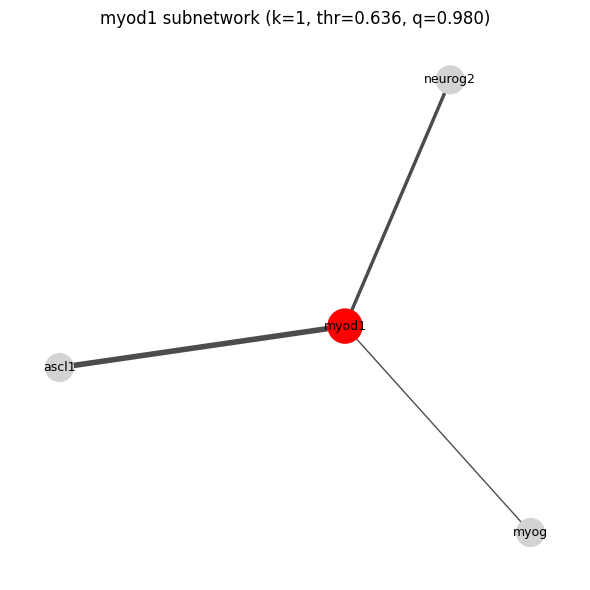

In [ ]:
all_cos_sim_myobl, df_edges_myobl = interpret_regulator_regulator_interactions(
    region="../data/myoblast_ENCFF647RNC_peak_100.bed",
    # region="../data/CTCF_ENCFF664UGR_sample100.bed",
    regulator="myod1",      # Plot subnetworks for these regulators
    odir="./output_regulator_network", # output directory
    ft_ckpt=ft_ckpt,  # fine-tuned checkpoint
    genome="hg38",                      # Options: "hg38", "mm10"
    resolution="1kb",                   # Options: "1kb", "2kb", "4kb", "200bp"
)

In [4]:
df_edges_myobl.query("node1 == 'myod1'")

,node1,node2,cosine_similarity
5177,myod1,myog,0.657007
5178,myod1,neurog2,0.671825
